<a href="https://colab.research.google.com/github/GeraldL19/Final-Year-Project-2024/blob/main/Sentiment_with_VADEr_trial_23_09_23.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import libraries
import pandas as pd

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
# nltk imports
from nltk.tokenize import word_tokenize  # tokenize the text == the text is splitted into words in list
from nltk.corpus import stopwords  # this contain common stop words that has no effect in analysis
from nltk.stem import WordNetLemmatizer  # Lemmatization is the process of grouping together the different inflected forms of a word so they can be analyzed as a single item

# download nltk corpus (first time only)
import nltk

nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package basque_grammars to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping grammars/basque_grammars.zip.
[nltk_data]    | Downloading package bcp47 to /root/nltk_data...
[nltk_data]    | Downloading package biocreative_ppi to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   U

True

In [ ]:
# Load the financial sentiment dataset
df = pd.read_csv('Financial Sentiement 1.csv')
df

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral
...,...,...
5837,RISING costs have forced packaging producer Hu...,negative
5838,Nordic Walking was first used as a summer trai...,neutral
5839,"According shipping company Viking Line , the E...",neutral
5840,"In the building and home improvement trade , s...",neutral


In [ ]:
df.shape

(5842, 2)

In [ ]:
unique_sentiments = df.Sentiment.unique()
unique_sentiments

array(['positive', 'negative', 'neutral'], dtype=object)

<Axes: >

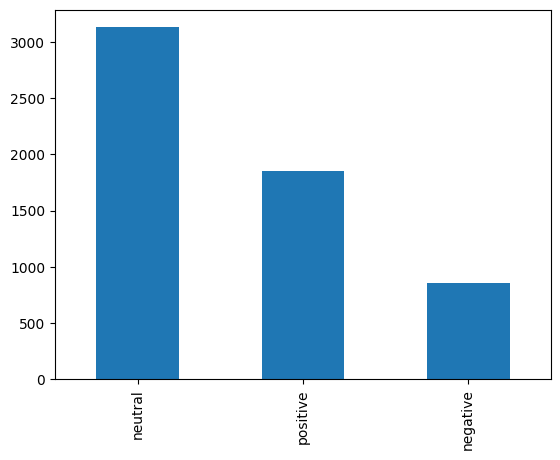

In [ ]:
df.Sentiment.value_counts().plot.bar()

In [ ]:
# mapping to the sentiment column i.e. replacing words (postive) with numbers (1)
dicto = {'positive': 1, 'neutral': 0 , 'negative': -1}
df.Sentiment = df.Sentiment.map(dicto)

In [ ]:
# create preprocess_text function
def preprocess_text(text):
    # Tokenize the text
    tokens = word_tokenize(text.lower())

    # Remove stop words
    filtered_tokens = [token for token in tokens if token not in stopwords.words('english')]

    # Lemmatize the tokens
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_tokens]

    # Join the tokens back into a string
    processed_text = ' '.join(lemmatized_tokens)
    return processed_text

# apply the function df
df['Sentence'] = df['Sentence'].apply(preprocess_text)
df

,Sentence,Sentiment
0,geosolutions technology leverage benefon 's gp...,1
1,"$ esi low , $ 1.50 $ 2.50 bk real possibility",-1
2,"last quarter 2010 , componenta 's net sale dou...",1
3,"according finnish-russian chamber commerce , m...",0
4,swedish buyout firm sold remaining 22.4 percen...,0
...,...,...
5837,rising cost forced packaging producer huhtamak...,-1
5838,nordic walking first used summer training meth...,0
5839,"according shipping company viking line , eu de...",0
5840,"building home improvement trade , sale decreas...",0


In [ ]:
!pip install vaderSentiment

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.4 MB/s eta 0:00:00


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

In [ ]:
analyser = SentimentIntensityAnalyzer()

In [ ]:
df['Scores'] = df['Sentence'].apply(lambda Sentence: analyser.polarity_scores(Sentence)['compound'])
df.head()

,Sentence,Sentiment,Scores
0,geosolutions technology leverage benefon 's gp...,1,0.6249
1,"$ esi low , $ 1.50 $ 2.50 bk real possibility",-1,-0.2732
2,"last quarter 2010 , componenta 's net sale dou...",1,0.1531
3,"according finnish-russian chamber commerce , m...",0,0.0000
4,swedish buyout firm sold remaining 22.4 percen...,0,0.0000


In [ ]:
def valuemaker(i):
  if i < -0.2:
    i = -1
  elif i > 0.2:
    i = 1
  else:
    i = 0
  return i

In [ ]:
df2 = df

df2['Scores'] = df2['Scores'].apply(valuemaker)
df2.head()

,Sentence,Sentiment,Scores
0,geosolutions technology leverage benefon 's gp...,1,1
1,"$ esi low , $ 1.50 $ 2.50 bk real possibility",-1,-1
2,"last quarter 2010 , componenta 's net sale dou...",1,0
3,"according finnish-russian chamber commerce , m...",0,0
4,swedish buyout firm sold remaining 22.4 percen...,0,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

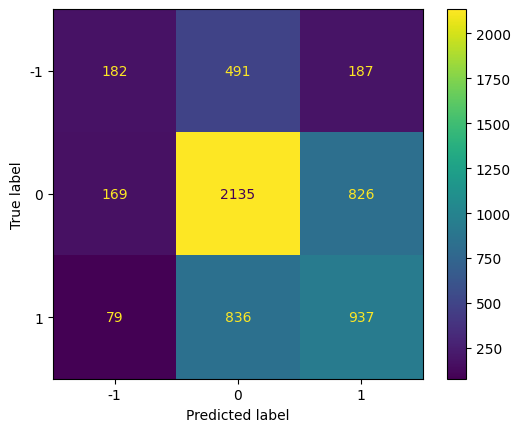

In [ ]:
labels = [-1,0,1]
cm = confusion_matrix(df2['Sentiment'], df2['Scores'], labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot();

In [ ]:
accuracy_score(df2['Sentiment'], df2['Scores'])

0.5217391304347826

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Split into training and testing data
x = df['Sentence']
y = df['Sentiment']
x, x_test, y, y_test = train_test_split(x,y, stratify=y, test_size=0.3, random_state=42)

In [ ]:
# Vectorize text reviews to numbers
vec = CountVectorizer(stop_words='english')
x = vec.fit_transform(x).toarray()
x_test = vec.transform(x_test).toarray()